# Robustness

In [1]:
%pwd

'/home/tzuhsuan/GitHub/QFoam/High-fidelity-Rydberg-control-Z-gates-with-time-optimal-pulses/Segmented500_53S_5L_BrrX/Segmented500_53S_5L_Brr50'

In [2]:
import os
import glob
import time
from IPython.display import clear_output

from qutip import *
import math

import numpy as np
import matplotlib.pyplot as plt
from IPython.display import display, clear_output

from rdquantum.pulse_shape import Saffman_shape
from rdquantum.fidelity import fidelity
from rdquantum.optimizer.de import de

plt.rcParams["figure.figsize"] = [5.5, 3.5]
plt.rcParams["figure.autolayout"] = True
plt.rcParams["axes.edgecolor"] = "black"
plt.rcParams["figure.facecolor"] = "white"
plt.rcParams["axes.linewidth"] = 2.50

# Physical system

In [3]:
### Hamiltonian ###
num_levels = 5    # 0, 1, p, r, d

def Hamiltonian(shape_omega1, value_omega2, value_delta1, value_doppler):
    I = qeye(num_levels)

    H_omega1 = (np.pi) * ( basis(num_levels,2)*basis(num_levels,1).dag() 
                          + basis(num_levels,1)*basis(num_levels,2).dag() )

    # Let Omega2, Delta1 and Delta2 be constants.
    value_delta = value_delta1[0]
    H_omega2 = (np.pi) * value_omega2[0] * ( basis(num_levels,3)*basis(num_levels,2).dag() 
                                            + basis(num_levels,2)*basis(num_levels,3).dag() )
    H_delta1 = (2*np.pi) * (value_delta1[0]+value_doppler[0]) * ( basis(num_levels,2)*basis(num_levels,2).dag() )
    H_delta = (2*np.pi) * value_doppler[0] * ( basis(num_levels,3)*basis(num_levels,3).dag() )

    B = (2*np.pi * 50)
    # Br = B * ( basis(num_levels,3)*basis(num_levels,3).dag() )
    
    # (MHz) Strength of Rydberg states interaction
    Brr = np.sqrt(B) * ( basis(num_levels,3)*basis(num_levels,3).dag() )
    Brr = tensor(Qobj(Brr), Qobj(Brr))

    H = [[tensor(H_omega1, I) + tensor(I, H_omega1), shape_omega1], 
         [tensor(H_omega2, I) + tensor(I, H_omega2), '1'], 
         [tensor(H_delta1, I) + tensor(I, H_delta1), '1'], 
         [tensor(H_delta, I) + tensor(I, H_delta), '1'],
         # [tensor(Br, I) + tensor(I, Br), '1'],
         [Brr, '1']]

    return H


### Pulse shape omega1(t), omega2(t) and delta1(t) ###
def PulseShape(times, Pulses, T_gate, n_seg):

    def shape_omega1(t, arg):
        return Saffman_shape(t, Pulses['Omega1'], T_gate, n_seg)

    value_omega2 = Pulses['Omega2']
    value_delta1 = Pulses['Delta1']
    value_doppler = Pulses['Doppler']
    # value_delta2 = Pulses['Delta2']
    
    return shape_omega1, value_omega2, value_delta1, value_doppler


### Decay term, c_ops ###
# def Decay(gammap=1/0.155, gammar=1/540):
def Decay(gammap=1/0.11, gammar=1/88):
    # gammap: (1/mu s) population decay rate of the Rydberg state
    # gammar: (1/mu s) population decay rate of the P state
    c_ops = []
    I = qeye(num_levels)
    
    # |p>
    L0p = np.sqrt(0.1354 * gammap) * ( basis(num_levels,0)*basis(num_levels,2).dag() )
    c_ops.append(tensor(Qobj(L0p), I))
    c_ops.append(tensor(I, Qobj(L0p)))

    L1p = np.sqrt(0.2504 * gammap) * ( basis(num_levels,1)*basis(num_levels,2).dag() )
    c_ops.append(tensor(Qobj(L1p), I))
    c_ops.append(tensor(I, Qobj(L1p)))
    
    Ldp = np.sqrt(0.6142 * gammap) * ( basis(num_levels,4)*basis(num_levels,2).dag() )
    c_ops.append(tensor(Qobj(Ldp), I))
    c_ops.append(tensor(I, Qobj(Ldp)))
    
    # |r>
    L0r = np.sqrt(0.053 * gammar) * ( basis(num_levels,0)*basis(num_levels,3).dag() )
    c_ops.append(tensor(Qobj(L0r), I))
    c_ops.append(tensor(I, Qobj(L0r)))

    L1r = np.sqrt(0.053 * gammar) * ( basis(num_levels,1)*basis(num_levels,3).dag() )
    c_ops.append(tensor(Qobj(L1r), I))
    c_ops.append(tensor(I, Qobj(L1r)))

    """
    Lpr = np.sqrt(0 * gammar) * ( basis(num_levels,2)*basis(num_levels,3).dag() )
    c_ops.append(tensor(Qobj(Lpr), I))
    c_ops.append(tensor(I, Qobj(Lpr)))
    """

    Ldr = np.sqrt(0.894 * gammar) * ( basis(num_levels,4)*basis(num_levels,3).dag() )
    c_ops.append(tensor(Qobj(Ldr), I))
    c_ops.append(tensor(I, Qobj(Ldr)))

    return c_ops

# Gate Operation

In [4]:
# Gate operation
def GateOp(Pulses, rho_init, targets):
    T_gate = Pulses['T_gate'][0]    # (mu s) Total gate time
    times = np.linspace(0.0, T_gate, 100)
    n_seg = 2*len(Omega1)   # Number of segments

    shape_omega1, value_omega2, value_delta1, value_doppler = PulseShape(times, Pulses, T_gate, n_seg)
    H = Hamiltonian(shape_omega1, value_omega2, value_delta1, value_doppler)
    c_ops = Decay(1/0.11, 1/88)
    
    results = mesolve(H, rho_init, times, c_ops, targets
                      , options=Options(nsteps=100000, rhs_reuse=False))
    return results

# Outpout

In [5]:
Had = np.zeros((num_levels,num_levels))
Had[0][0] = 1
Had[0][1] = 1
Had[1][0] = 1
Had[1][1] = -1

I = qeye(num_levels)
Had = Qobj(Had/np.sqrt(2))

ket00 = tensor(basis(num_levels,0), basis(num_levels,0))
ket01 = tensor(basis(num_levels,0), basis(num_levels,1))
ket10 = tensor(basis(num_levels,1), basis(num_levels,0))
ket11 = tensor(basis(num_levels,1), basis(num_levels,1))

# Target Bell state, rho_bell = 1/sqrt(2) * (|01> + |10>)
rho0101 = tensor(I, Had) * ket2dm(ket01) * tensor(I, Had)
rho1010 = tensor(I, Had) * ket2dm(ket10) * tensor(I, Had)
rho0110 = tensor(I, Had) * (ket10 * ket01.dag()) * tensor(I, Had)
rho_bell = [rho0101, rho1010, rho0110]

# Initial state, rhoi = |01><01|
rhoi = tensor(Had, Had) * ket2dm(ket01) * tensor(Had, Had)

bell_fidelity = fidelity(GateOp, rhoi, rho_bell)
# print(bell_fidelity.get_fidelity(Pulses))

In [6]:
oppulse_file = "./out-op_pulse.npz"
oppulse = np.load(oppulse_file, allow_pickle=True)

Omega1 = oppulse['Omega1']
Omega2 = oppulse['Omega2']
Delta1 = oppulse['Delta1']
T_gate = oppulse['T_gate']

Pulses = {'Omega1': Omega1, 'Omega2': Omega2, 
          'Delta1': Delta1, 'Doppler': [0],
          'T_gate': T_gate}

# Loop temperature
Kb = 1.38*10**(-23)     #(m^2 Kg / s^2 K)
m = 1.5*10**(-25)       #(Kg) Rubidium 87 
kp = 1/ (420*10**(-9))  #(1/m)
# T = np.arange(0, 12*10**(6), 1*10**(6)) #(\mu K)
T = np.arange(0, 101, 5) #(\mu K)
Omp = np.arange(-0.1, 0.12, 0.02)
fi = np.zeros((len(Omp), len(T)))
for i in range(len(T)):
    temp = T[i]*(10**(-6))
    if temp == 0:
        vrms = 0
    else: 
        vrms = (temp/abs(temp)) * np.sqrt(Kb*np.abs(temp)/m)
    Pulses['Doppler'][0] = kp*vrms*(10**(-6))
    for j in range(len(Omp)):
        tempP = Pulses['Omega1']
        tempR = Pulses['Omega2']
        Pulses['Omega1'] = tempP*(1+Omp[j])
        Pulses['Omega2'] = tempR*(1+Omp[j])
        fi[j][i] = bell_fidelity.get_fidelity(Pulses)
        Pulses['Omega1'] = tempP
        Pulses['Omega2'] = tempR

np.save('out_roubustness', fi)

Text(0, 0.5, '$\\delta \\Omega(t) / \\Omega(t)$')

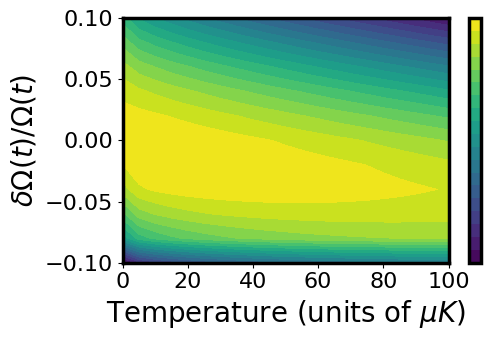

In [7]:
z = fi

plt.xticks(fontsize=16)
plt.yticks(fontsize=16)

lv = np.linspace(np.min(z), np.max(z), 20)
# plt.figure(figsize=(8,6))
cs = plt.contourf(T, Omp, z,levels=lv)

yinterval = np.arange(-0.1, 0.11, 0.05)
plt.yticks(yinterval)

cbar = plt.colorbar(cs, ticks=np.arange(0.93, 0.992, 0.02))
cbar.ax.tick_params(labelsize=16)

plt.xlabel('Temperature' ' (units of ' r'$\mu K$' ')', fontsize=20)
plt.ylabel(r'$\delta \Omega(t) / \Omega(t)$', fontsize=20)
# plt.show()
# plt.savefig('1000_gau_db.png', dpi=1200)